In [ ]:
from re import sub
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

df=pd.read_csv("/content/drive/MyDrive/proyectos practica data analyst/asos analysis/products_asos.csv")

df["price"]=pd.to_numeric(df["price"],errors="coerce")
df=df.dropna(subset=["price"])
print(f"datos cargados : {len(df)} filas")
df.head()

datos cargados : 18378 filas


,url,name,size,category,price,color,sku,description,images
0,https://www.asos.com/stradivarius/stradivarius...,New Look trench coat in camel,"UK 4,UK 6,UK 8,UK 10,UK 12,UK 14 - Out of stoc...",New Look trench coat in camel,49.99,Neutral,126704571.0,[{'Product Details': 'Coats & Jackets by New L...,['https://images.asos-media.com/products/new-l...
1,https://www.asos.com/stradivarius/stradivarius...,New Look trench coat in camel,"UK 4,UK 6,UK 8,UK 10,UK 12,UK 14 - Out of stoc...",New Look trench coat in camel,49.99,Neutral,126704571.0,[{'Product Details': 'Coats & Jackets by New L...,['https://images.asos-media.com/products/new-l...
2,https://www.asos.com/asos-design/asos-design-l...,New Look trench coat in camel,"UK 4,UK 6,UK 8,UK 10,UK 12,UK 14 - Out of stoc...",New Look trench coat in camel,49.99,Neutral,126704571.0,[{'Product Details': 'Coats & Jackets by New L...,['https://images.asos-media.com/products/new-l...
3,https://www.asos.com/new-look/new-look-trench-...,New Look trench coat in camel,"UK 4,UK 6,UK 8,UK 10,UK 12,UK 14 - Out of stoc...",New Look trench coat in camel,49.99,Neutral,126704571.0,[{'Product Details': 'Coats & Jackets by New L...,['https://images.asos-media.com/products/new-l...
4,https://www.asos.com/stradivarius/stradivarius...,Stradivarius double breasted wool coat in grey,"XS - UK 6,S - UK 8,M - UK 10,L - UK 12,XL - UK 14",Stradivarius double breasted wool coat in grey,59.99,GREY,123650194.0,[{'Product Details': 'Coats & Jackets by Strad...,['https://images.asos-media.com/products/strad...


In [ ]:
df['description']=df['description'].astype(str)
def obtener_marca(text):
  if 'by' in text:
    try:
      return text.split('by ')[1].split(' ')[0]
    except:
      return "desconocido"
  return "desconocido"

df["fila_marca"]=df["description"].apply(obtener_marca)


In [ ]:
df.head(3)

,url,name,size,category,price,color,sku,description,images,fila_marca
0,https://www.asos.com/stradivarius/stradivarius...,New Look trench coat in camel,"UK 4,UK 6,UK 8,UK 10,UK 12,UK 14 - Out of stoc...",New Look trench coat in camel,49.99,Neutral,126704571.0,[{'Product Details': 'Coats & Jackets by New L...,['https://images.asos-media.com/products/new-l...,New
1,https://www.asos.com/stradivarius/stradivarius...,New Look trench coat in camel,"UK 4,UK 6,UK 8,UK 10,UK 12,UK 14 - Out of stoc...",New Look trench coat in camel,49.99,Neutral,126704571.0,[{'Product Details': 'Coats & Jackets by New L...,['https://images.asos-media.com/products/new-l...,New
2,https://www.asos.com/asos-design/asos-design-l...,New Look trench coat in camel,"UK 4,UK 6,UK 8,UK 10,UK 12,UK 14 - Out of stoc...",New Look trench coat in camel,49.99,Neutral,126704571.0,[{'Product Details': 'Coats & Jackets by New L...,['https://images.asos-media.com/products/new-l...,New


In [ ]:
marca_map={
    'New':'New Look',
    'River':'River Island',
    'Miss':'Miss Selfridge',
    'TopshopeWelcome':'Topshop'
}
df["marca"]=df["fila_marca"].map(marca_map).fillna(df['fila_marca'])

contar_marcas=df['marca'].value_counts()
marcas_validas=contar_marcas[contar_marcas>=5].index
df_limpio=df[df["marca"].isin(marcas_validas)].copy()

print(df_limpio["marca"].value_counts().head(5))
df_limpio["marca"].head()

marca
ASOS              4844
TopshopWelcome     711
New Look           511
River Island       467
Miss Selfridge     429
Name: count, dtype: int64


,marca
0,New Look
1,New Look
2,New Look
3,New Look
4,StradivariusJacket


In [ ]:
def calcular_ingresos_fantasmas(size_str):
    if not isinstance(size_str, str):
        return 0, 0.0

    sizes = size_str.split(",")
    total_sizes = len(sizes)

    contar_fuera_de_stock = size_str.lower().count("out of stock")

    tasa_de_agotados = contar_fuera_de_stock / total_sizes if total_sizes > 0 else 0.0

    return contar_fuera_de_stock, tasa_de_agotados


metricas = df_limpio['size'].apply(lambda x: calcular_ingresos_fantasmas(x))


df_limpio["contar_fuera_de_stock"] = [x[0] for x in metricas]
df_limpio["fuera_de_stock_tasa"] = [x[1] for x in metricas]

df_limpio["ingresos_fantasmas"] = df_limpio["price"] * df_limpio["contar_fuera_de_stock"]

columnas = ["marca", "name", "price", "contar_fuera_de_stock", "ingresos_fantasmas"]
print(df_limpio.sort_values(by="ingresos_fantasmas", ascending=False).head(5)[columnas])

                  marca                                               name  \
2941            Barbour               Barbour Beadnell wax jacket in black   
2679   BarbourExclusive  Barbour x ASOS exclusive Stephanie wax parka i...   
21948    TopshopWelcome  Topshop premium real leather collared zip thro...   
2715               ASOS  ASOS DESIGN premium real leather trench coat i...   
15584              ASOS  ASOS EDITION geo embellished fringe plunge mid...   

       price  contar_fuera_de_stock  ingresos_fantasmas  
2941   219.0                      9              1971.0  
2679   279.0                      7              1953.0  
21948  260.0                      7              1820.0  
2715   220.0                      7              1540.0  
15584  250.0                      6              1500.0  


/tmp/ipykernel_1772/530462331.py:12: UserWarning: Ignoring `palette` because no `hue` variable has been assigned.
  sns.scatterplot(


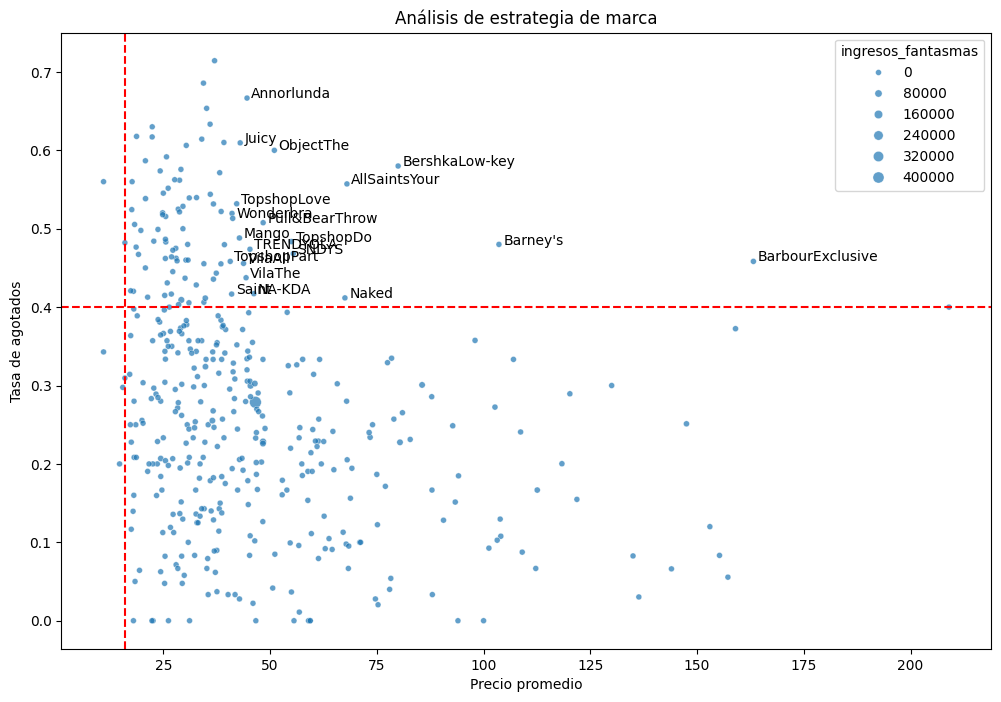

In [ ]:

estrategia_marca = df_limpio.groupby("marca").agg({
    "price": "mean",
    "fuera_de_stock_tasa": "mean",
    "ingresos_fantasmas": "sum",
    "name": "count"
}).reset_index()


estrategia_marca = estrategia_marca.rename(columns={"name": "total_productos"})

plt.figure(figsize=(12, 8))
sns.scatterplot(
    data=estrategia_marca,
    x="price",
    y="fuera_de_stock_tasa",
    size="ingresos_fantasmas",
    alpha=0.7,
    palette="#4C8CBF"
)

ganadores = estrategia_marca[
    (estrategia_marca["price"] > 40) &
    (estrategia_marca["fuera_de_stock_tasa"] > 0.4)
]

for i in range(len(ganadores)):
    plt.text(
        ganadores.iloc[i]["price"] + 1,
        ganadores.iloc[i]["fuera_de_stock_tasa"],
        ganadores.iloc[i]["marca"]
    )

plt.title("Análisis de estrategia de marca")
plt.xlabel("Precio promedio")
plt.ylabel("Tasa de agotados")
plt.axvline(x=16, color="red", linestyle="--")
plt.axhline(y=0.4, color="red", linestyle="--")
plt.show()